## Feature Engineering Notebook

In [1]:
#imports
import pandas as pd
import sweetviz as sv
from sklearn.model_selection import train_test_split
import numpy as np
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import balanced_accuracy_score, classification_report
from sklearn.model_selection import cross_val_score
import optuna
from sklearn.utils import compute_class_weight
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import StratifiedKFold
from sklearn.inspection import permutation_importance
import shap

In [2]:
#read in and view training data
training = pd.read_csv("C:\\Users\\donya\\Documents\\GSB 545\\GSB-545\\train.csv")
training.head()

,id,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,...,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region,Irrigation_Need
0,0,Loamy,4.92,32.58,1.01,3.05,15.01,50.61,725.99,5.90,...,Sugarcane,Sowing,Zaid,Drip,Rainwater,0.82,No,112.16,East,Low
1,1,Clay,7.08,56.61,0.44,2.00,22.92,67.86,985.66,6.98,...,Wheat,Vegetative,Kharif,Rainfed,River,5.27,Yes,47.16,South,Low
2,2,Clay,5.69,27.71,0.81,2.83,26.97,92.22,2201.70,6.05,...,Rice,Vegetative,Kharif,Sprinkler,Reservoir,8.24,Yes,110.38,North,Low
3,3,Sandy,5.65,13.32,1.33,0.87,13.32,61.57,1357.33,9.12,...,Wheat,Flowering,Kharif,Canal,River,8.32,Yes,53.85,South,Medium
4,4,Clay,7.96,59.14,0.38,0.96,20.22,91.11,1538.20,6.95,...,Wheat,Sowing,Rabi,Canal,River,7.37,No,93.19,South,Low


In [3]:
#read in and view test data
test = pd.read_csv("C:\\Users\\donya\\Documents\\GSB 545\\GSB-545\\test.csv")
test.head()

,id,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region
0,630000,Silt,6.36,26.19,0.59,2.81,17.83,30.24,1533.38,5.40,3.00,Maize,Sowing,Rabi,Canal,River,13.59,Yes,47.48,West
1,630001,Clay,5.87,9.88,1.18,3.26,21.18,78.07,576.05,7.22,15.88,Cotton,Sowing,Rabi,Drip,Reservoir,6.12,Yes,56.43,South
2,630002,Sandy,6.22,26.55,0.96,0.85,26.87,60.35,545.30,9.43,2.63,Wheat,Sowing,Kharif,Sprinkler,Reservoir,3.11,Yes,20.00,East
3,630003,Clay,7.68,53.58,0.83,0.55,41.74,36.05,1211.03,6.69,1.86,Maize,Harvest,Rabi,Canal,Groundwater,2.27,No,102.99,North
4,630004,Loamy,5.23,59.02,0.54,2.11,41.08,52.47,1321.91,4.11,5.71,Cotton,Sowing,Kharif,Canal,Groundwater,12.39,Yes,13.33,Central


In [4]:
#display summary statistics of quantitative variables in training data
training.describe()

,id,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Field_Area_hectare,Previous_Irrigation_mm
count,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000
mean,314999.500000,6.482497,37.304482,0.922858,1.744605,26.998166,61.563180,1462.207566,7.513382,10.375394,7.517745,62.318177
std,181865.479132,0.922504,16.377082,0.365808,0.952321,8.623621,19.708152,612.989738,1.999322,5.689458,4.218124,34.246939
min,0.000000,4.800000,8.000000,0.300000,0.100000,12.000000,25.000000,0.380000,4.000000,0.500000,0.300000,0.020000
25%,157499.750000,5.690000,23.340000,0.610000,0.930000,19.517500,45.390000,954.570000,5.760000,5.280000,3.880000,33.140000
50%,314999.500000,6.440000,37.750000,0.910000,1.740000,26.960000,61.650000,1467.160000,7.580000,10.480000,7.380000,61.150000
75%,472499.250000,7.270000,51.270000,1.220000,2.580000,34.540000,79.120000,2054.280000,9.250000,15.430000,11.140000,92.690000
max,629999.000000,8.200000,64.990000,1.600000,3.500000,42.000000,94.990000,2499.690000,11.000000,20.000000,15.000000,119.990000


In [5]:
#unique values for each category (courtesty of @wesleyhuan's notebook)
categorical_variables = training.select_dtypes(include=["str"]).columns.tolist()
for column in categorical_variables:
    print(column, ":", training[column].unique())

Soil_Type : <ArrowStringArray>
['Loamy', 'Clay', 'Sandy', 'Silt']
Length: 4, dtype: str
Crop_Type : <ArrowStringArray>
['Sugarcane', 'Wheat', 'Rice', 'Potato', 'Cotton', 'Maize']
Length: 6, dtype: str
Crop_Growth_Stage : <ArrowStringArray>
['Sowing', 'Vegetative', 'Flowering', 'Harvest']
Length: 4, dtype: str
Season : <ArrowStringArray>
['Zaid', 'Kharif', 'Rabi']
Length: 3, dtype: str
Irrigation_Type : <ArrowStringArray>
['Drip', 'Rainfed', 'Sprinkler', 'Canal']
Length: 4, dtype: str
Water_Source : <ArrowStringArray>
['Rainwater', 'River', 'Reservoir', 'Groundwater']
Length: 4, dtype: str
Mulching_Used : <ArrowStringArray>
['No', 'Yes']
Length: 2, dtype: str
Region : <ArrowStringArray>
['East', 'South', 'North', 'West', 'Central']
Length: 5, dtype: str
Irrigation_Need : <ArrowStringArray>
['Low', 'Medium', 'High']
Length: 3, dtype: str


# Feature engineering

In [6]:
#make a copy of the original dataset and split data
training_fe = training.copy()

## Transformations of features (to fix skew)

In [7]:
#quick sweetviz visualizations to show original feature distributions
report = sv.analyze(training_fe)
report.show_html("hw4_report.html")

                                             |          | [  0%]   00:00 -> (? left)

Report hw4_report.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.


The features are not very skewed. Transformations to fix skew of the features does not seem appropriate for this data.

After doing some research into the dataset and reviewing other Kaggle notebooks, it appears that a large amount of the feature engineering is defined using domain knowledge. Therfore, the following features have been created using outside research and examples from other Kaggle authors. The authors whose engineered features are used in my notebook are referenced at the bottom.

In [8]:
# Start off by one-hot encoding categorical variables
cat_columns = ['Soil_Type',
 'Crop_Type',
 'Crop_Growth_Stage',
 'Season',
 'Irrigation_Type',
 'Water_Source',
 'Mulching_Used',
 'Region']
training_fe = pd.get_dummies(training_fe, columns=cat_columns)*1
training_fe.head()

,id,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,...,Water_Source_Rainwater,Water_Source_Reservoir,Water_Source_River,Mulching_Used_No,Mulching_Used_Yes,Region_Central,Region_East,Region_North,Region_South,Region_West
0,0,4.92,32.58,1.01,3.05,15.01,50.61,725.99,5.90,16.79,...,1,0,0,1,0,0,1,0,0,0
1,1,7.08,56.61,0.44,2.00,22.92,67.86,985.66,6.98,3.39,...,0,0,1,0,1,0,0,0,1,0
2,2,5.69,27.71,0.81,2.83,26.97,92.22,2201.70,6.05,3.85,...,0,1,0,0,1,0,0,1,0,0
3,3,5.65,13.32,1.33,0.87,13.32,61.57,1357.33,9.12,2.31,...,0,0,1,0,1,0,0,0,1,0
4,4,7.96,59.14,0.38,0.96,20.22,91.11,1538.20,6.95,13.94,...,0,0,1,1,0,0,0,0,1,0


In [9]:
# Transformed features

# Evapotranspiration proxy — heat + wind drives water loss
training_fe['Evapotranspiration_Index'] = training_fe['Temperature_C'] * training_fe['Wind_Speed_kmh'] / (training_fe['Humidity'] + 1)

# Soil water retention capacity
training_fe['Log_Soil_Moisture'] = np.log1p(training_fe['Soil_Moisture'])

# pH deviation from neutral (7.0) — stress indicator
training_fe['pH_Deviation'] = abs(training_fe['Soil_pH'] - 7.0)

# Soil health
training_fe['Soil_health'] = training_fe['Organic_Carbon']*training_fe['Soil_Moisture']/(training_fe['Electrical_Conductivity']+0.1)

# Total water input
training_fe['Total_water_input'] = training_fe['Rainfall_mm'] + training_fe['Previous_Irrigation_mm']

#Interactions

# Mulch interaction
training_fe['Mulch_moisture'] = training_fe['Soil_Moisture']*training_fe['Mulching_Used_Yes']

# Moisture retention
training_fe['Moisture_retention'] = training_fe['Soil_Moisture']*training_fe['Organic_Carbon']

# Soil moisture and temperature interaction
training_fe['moist_temp'] = training_fe['Soil_Moisture']*training_fe['Temperature_C']

# temperature and wind interaction
training_fe['temp_wind'] = training_fe['Temperature_C']*training_fe['Wind_Speed_kmh']

# temperature and humidity interaction
training_fe["temp_humidity"] = training_fe['Temperature_C']*training_fe['Humidity']

# Polynomials (squared predictors)

training_fe['Temp_Squared'] = training_fe['Temperature_C'] ** 2
training_fe['Wind_Squared'] = training_fe['Wind_Speed_kmh'] ** 2
training_fe['Moisture_Squared'] = training_fe['Soil_Moisture'] ** 2

#Polynomials (cubed predictors)
training_fe['Temp_Cubed'] = training_fe['Temperature_C'] ** 3
training_fe['Wind_Cubed'] = training_fe['Wind_Speed_kmh'] ** 3

In [10]:
training_fe.head()

,id,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,...,Mulch_moisture,Moisture_retention,moist_temp,temp_wind,temp_humidity,Temp_Squared,Wind_Squared,Moisture_Squared,Temp_Cubed,Wind_Cubed
0,0,4.92,32.58,1.01,3.05,15.01,50.61,725.99,5.90,16.79,...,0.00,32.9058,489.0258,252.0179,759.6561,225.3001,281.9041,1061.4564,3381.754501,4733.169839
1,1,7.08,56.61,0.44,2.00,22.92,67.86,985.66,6.98,3.39,...,56.61,24.9084,1297.5012,77.6988,1555.3512,525.3264,11.4921,3204.6921,12040.481088,38.958219
2,2,5.69,27.71,0.81,2.83,26.97,92.22,2201.70,6.05,3.85,...,27.71,22.4451,747.3387,103.8345,2487.1734,727.3809,14.8225,767.8441,19617.462873,57.066625
3,3,5.65,13.32,1.33,0.87,13.32,61.57,1357.33,9.12,2.31,...,13.32,17.7156,177.4224,30.7692,820.1124,177.4224,5.3361,177.4224,2363.266368,12.326391
4,4,7.96,59.14,0.38,0.96,20.22,91.11,1538.20,6.95,13.94,...,0.00,22.4732,1195.8108,281.8668,1842.2442,408.8484,194.3236,3497.5396,8266.914648,2708.870984


In [11]:
X = training_fe.drop(["Irrigation_Need", "id"], axis=1)
y = training_fe["Irrigation_Need"]

# split data
X_train_fe, X_test_fe, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=321, stratify=y
)

In [12]:
#label encoding for XGBoost
le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_test  = le.transform(y_test)

# Check the mapping
print(dict(zip(le.classes_, le.transform(le.classes_))))

{'High': np.int64(0), 'Low': np.int64(1), 'Medium': np.int64(2)}


In [13]:
X.head()

,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Field_Area_hectare,...,Mulch_moisture,Moisture_retention,moist_temp,temp_wind,temp_humidity,Temp_Squared,Wind_Squared,Moisture_Squared,Temp_Cubed,Wind_Cubed
0,4.92,32.58,1.01,3.05,15.01,50.61,725.99,5.90,16.79,0.82,...,0.00,32.9058,489.0258,252.0179,759.6561,225.3001,281.9041,1061.4564,3381.754501,4733.169839
1,7.08,56.61,0.44,2.00,22.92,67.86,985.66,6.98,3.39,5.27,...,56.61,24.9084,1297.5012,77.6988,1555.3512,525.3264,11.4921,3204.6921,12040.481088,38.958219
2,5.69,27.71,0.81,2.83,26.97,92.22,2201.70,6.05,3.85,8.24,...,27.71,22.4451,747.3387,103.8345,2487.1734,727.3809,14.8225,767.8441,19617.462873,57.066625
3,5.65,13.32,1.33,0.87,13.32,61.57,1357.33,9.12,2.31,8.32,...,13.32,17.7156,177.4224,30.7692,820.1124,177.4224,5.3361,177.4224,2363.266368,12.326391
4,7.96,59.14,0.38,0.96,20.22,91.11,1538.20,6.95,13.94,7.37,...,0.00,22.4732,1195.8108,281.8668,1842.2442,408.8484,194.3236,3497.5396,8266.914648,2708.870984


In [14]:
y.head()

0       Low
1       Low
2       Low
3    Medium
4       Low
Name: Irrigation_Need, dtype: str

## Feature importance: Testing new feature set with baseline models

In [15]:
#class weights calculation for XGBoost
weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
weights

array([9.99583507, 0.56769415, 0.87839004])

In [16]:
#define baseline models

#XGBoost baseline
xgb_model = XGBClassifier(
    objective='multi:softprob',
    num_class=3,                 
    random_state=321
)

#LGBoost baseline
lgb_model = LGBMClassifier(
    objective='multiclass',
    num_class=3,        
    class_weight='balanced', 
    random_state=321
)

#Catboost baseline
catboost_model = CatBoostClassifier(
    loss_function='MultiClass',  # multiclass classification
    auto_class_weights='Balanced',  # handles imbalance automatically
    random_state=42,
    verbose=0
)

In [17]:
#define cross-validation strategy
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=321)

In [18]:
#run baseline models with full engineered feature set - XGBoost
cv_scores_xgb = cross_val_score(xgb_model, X_train_fe, y_train, cv=cv, scoring="balanced_accuracy", n_jobs=-1)
print(cv_scores_xgb)
print(cv_scores_xgb.mean())
print(cv_scores_xgb.std())

xgb_model.fit(X_train_fe, y_train)

#evaluate final model performance on held out test set
y_pred = xgb_model.predict(X_test_fe)
print("XGBoost Baseline Balanced Accuracy Score (Full feature set):", balanced_accuracy_score(y_test, y_pred))
print("Classification Report:")
print(classification_report(y_test, y_pred))

[0.96011765 0.96372276 0.96063684 0.95997259 0.96375133]
0.9616402330089638
0.0017262541565896032
XGBoost Baseline Balanced Accuracy Score (Full feature set): 0.96168316376228
Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.92      0.94      4202
           1       0.99      0.99      0.99     73983
           2       0.98      0.97      0.98     47815

    accuracy                           0.98    126000
   macro avg       0.98      0.96      0.97    126000
weighted avg       0.98      0.98      0.98    126000



In [19]:
#run baseline models with full engineered feature set - LGBoost
cv_scores_lgb = cross_val_score(lgb_model, X_train_fe, y_train, cv=cv, scoring="balanced_accuracy", n_jobs=-1)
print(cv_scores_lgb)
print(cv_scores_lgb.mean())
print(cv_scores_lgb.std())

lgb_model.fit(X_train_fe, y_train)

#evaluate final model performance on held out test set
y_pred = lgb_model.predict(X_test_fe)
print("LGBoost Baseline Balanced Accuracy Score (Full feature set):", balanced_accuracy_score(y_test, y_pred))
print("Classification Report:")
print(classification_report(y_test, y_pred))

[0.96881394 0.9696721  0.96907882 0.96769427 0.96924038]
0.9688999022593752
0.0006641040376586555
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.069902 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6529
[LightGBM] [Info] Number of data points in the train set: 504000, number of used features: 58
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
LGBoost Baseline Balanced Accuracy Score (Full feature set): 0.9676428359167676
Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.94      0.90      4202
           1       0.99      0.99      0.99     73983
           2       0.99      0.96      0.98     47815

    accuracy                           0.98    126000
   macro avg       0.94      0.97      0.95    126000
weighted avg       0.

In [20]:
#run baseline models with full engineered feature set - Catboost

#need to use manual fold loop because of cloning error
cv_scores_cb_baseline = []

for train_idx, val_idx in cv.split(X_train_fe, y_train):
    X_fold_train, X_fold_val = X_train_fe.iloc[train_idx], X_train_fe.iloc[val_idx]
    y_fold_train, y_fold_val = y_train[train_idx], y_train[val_idx]  # numpy indexing

    catboost_model.fit(X_fold_train, y_fold_train)

    y_pred_fold = catboost_model.predict(X_fold_val)

    cv_scores_cb_baseline.append(balanced_accuracy_score(y_fold_val, y_pred_fold))

print(cv_scores_cb_baseline)
print(np.mean(cv_scores_cb_baseline))
print(np.std(cv_scores_cb_baseline))

catboost_model.fit(X_train_fe, y_train)

# Evaluate final model performance on held out test set
y_pred = catboost_model.predict(X_test_fe)
print("CatBoost Balanced Accuracy Score:", balanced_accuracy_score(y_test, y_pred))
print("Classification Report:")
print(classification_report(y_test, y_pred))

[0.968555637221676, 0.967970360194328, 0.9694026002629105, 0.9671789242938228, 0.9677894480435683]
0.9681793940032613
0.0007529256453741032
CatBoost Balanced Accuracy Score: 0.9674263760249685
Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.94      0.91      4202
           1       0.99      0.99      0.99     73983
           2       0.99      0.97      0.98     47815

    accuracy                           0.98    126000
   macro avg       0.95      0.97      0.96    126000
weighted avg       0.98      0.98      0.98    126000



## Feature importance: Selecting the most important features using feature importance, permutation importance, and SHAP

Feature importance and permutation importance

In [21]:
# Rank and display feature importances from baseline models using feature data
xgb_importances = pd.Series(xgb_model.feature_importances_, index=X_train_fe.columns).sort_values(ascending=False)
lgb_importances = pd.Series(lgb_model.feature_importances_, index=X_train_fe.columns).sort_values(ascending=False)
catboost_importances = pd.Series(catboost_model.feature_importances_, index=X_train_fe.columns).sort_values(ascending=False)
print("Top 10 XGBoost Feature Importances:")
print(xgb_importances.head(10))
print("\nTop 10 LG Boost Feature Importances:")
print(lgb_importances.head(10))
print("\nTop 10 CatBoost Feature Importances:")
print(catboost_importances.head(10))

Top 10 XGBoost Feature Importances:
Crop_Growth_Stage_Vegetative    0.224333
Crop_Growth_Stage_Flowering     0.152644
Mulching_Used_No                0.142692
Crop_Growth_Stage_Sowing        0.119315
Soil_Moisture                   0.091154
Crop_Growth_Stage_Harvest       0.088820
Temperature_C                   0.041689
Wind_Speed_kmh                  0.036114
Mulch_moisture                  0.034395
temp_wind                       0.022703
dtype: float32

Top 10 LG Boost Feature Importances:
Rainfall_mm                  982
Temperature_C                865
Soil_Moisture                758
Wind_Speed_kmh               664
Mulching_Used_No             509
Crop_Growth_Stage_Harvest    479
Total_water_input            457
Crop_Growth_Stage_Sowing     455
Previous_Irrigation_mm       426
Humidity                     368
dtype: int32

Top 10 CatBoost Feature Importances:
Crop_Growth_Stage_Harvest    9.702719
Soil_Moisture                8.729041
Crop_Growth_Stage_Sowing     8.159182
Log_So

In [22]:
# Rank and display permutation importances for baseline models

xgb_perm_importance = permutation_importance(xgb_model, X_test_fe, y_test, n_repeats=10, random_state=321)
lgb_perm_importance = permutation_importance(lgb_model, X_test_fe, y_test, n_repeats=10, random_state=321)
catboost_perm_importance = permutation_importance(catboost_model, X_test_fe, y_test, n_repeats=10, random_state=321)

# saving permutation importance results in DataFrames for easier display
xgb_perm_importance_df = pd.DataFrame({
    'feature': X_test_fe.columns,
    'importance_mean': xgb_perm_importance.importances_mean,
    'importance_std': xgb_perm_importance.importances_std
}).sort_values(by='importance_mean', ascending=False)

lgb_perm_importance_df = pd.DataFrame({
    'feature': X_test_fe.columns,
    'importance_mean': lgb_perm_importance.importances_mean,
    'importance_std': lgb_perm_importance.importances_std
}).sort_values(by='importance_mean', ascending=False)

catboost_perm_importance_df = pd.DataFrame({
    'feature': X_test_fe.columns,
    'importance_mean': catboost_perm_importance.importances_mean,
    'importance_std': catboost_perm_importance.importances_std
}).sort_values(by='importance_mean', ascending=False)

# display top 10 features by permutation importance for both models
print("Top 10 XGBoost Permutation Importances:")
print(xgb_perm_importance_df.head(10))
print("\nTop 10 LG Boost Permutation Importances:")
print(lgb_perm_importance_df.head(10))
print("\nTop 10 CatBoost Permutation Importances:")
print(catboost_perm_importance_df.head(10))

Top 10 XGBoost Permutation Importances:
                         feature  importance_mean  importance_std
1                  Soil_Moisture         0.177752        0.000519
22     Crop_Growth_Stage_Harvest         0.115097        0.000390
4                  Temperature_C         0.108729        0.000604
8                 Wind_Speed_kmh         0.105721        0.000766
23      Crop_Growth_Stage_Sowing         0.098544        0.000292
36              Mulching_Used_No         0.067754        0.000303
48                Mulch_moisture         0.046909        0.000453
21   Crop_Growth_Stage_Flowering         0.016187        0.000211
24  Crop_Growth_Stage_Vegetative         0.014910        0.000329
6                    Rainfall_mm         0.009532        0.000148

Top 10 LG Boost Permutation Importances:
                         feature  importance_mean  importance_std
1                  Soil_Moisture         0.172455        0.000573
22     Crop_Growth_Stage_Harvest         0.127068        0.0

In [23]:
# XGBoost averaged rankings
xgb_feat_df = pd.DataFrame({
    "feature": X_train_fe.columns,
    "feat_importance": xgb_model.feature_importances_
})

#rank feature importance and permutation importance results
xgb_feat_df["rank_feat"] = xgb_feat_df["feat_importance"].rank(ascending=False)
xgb_perm_importance_df["rank_perm"] = xgb_perm_importance_df["importance_mean"].rank(ascending=False)

#merge
xgb_combined = (
    xgb_feat_df
    .merge(xgb_perm_importance_df[["feature", "importance_mean", "rank_perm"]], on="feature")
)

#average ranks
xgb_combined["rank_avg"] = (xgb_combined["rank_feat"] + xgb_combined["rank_perm"]) / 2

#sort and display top 30 features
xgb_combined = xgb_combined.sort_values("rank_avg")
xgb_top_features = xgb_combined.head(30)
xgb_top_features

,feature,feat_importance,rank_feat,importance_mean,rank_perm,rank_avg
1,Soil_Moisture,0.091154,5.0,0.177752,1.0,3.00
22,Crop_Growth_Stage_Harvest,0.088820,6.0,0.115097,2.0,4.00
23,Crop_Growth_Stage_Sowing,0.119315,4.0,0.098544,5.0,4.50
36,Mulching_Used_No,0.142692,3.0,0.067754,6.0,4.50
24,Crop_Growth_Stage_Vegetative,0.224333,1.0,0.014910,9.0,5.00
21,Crop_Growth_Stage_Flowering,0.152644,2.0,0.016187,8.0,5.00
4,Temperature_C,0.041689,7.0,0.108729,3.0,5.00
8,Wind_Speed_kmh,0.036114,8.0,0.105721,4.0,6.00
48,Mulch_moisture,0.034395,9.0,0.046909,7.0,8.00
6,Rainfall_mm,0.014428,11.0,0.009532,10.0,10.50


In [24]:
# LG Boost averaged rankings
lgb_feat_df = pd.DataFrame({
    "feature": X_train_fe.columns,
    "feat_importance": lgb_model.feature_importances_
})

#rank feature importance and permutation importance results
lgb_feat_df["rank_feat"] = lgb_feat_df["feat_importance"].rank(ascending=False)
lgb_perm_importance_df["rank_perm"] = lgb_perm_importance_df["importance_mean"].rank(ascending=False)

#merge
lgb_combined = (
    lgb_feat_df
    .merge(lgb_perm_importance_df[["feature", "importance_mean", "rank_perm"]], on="feature")
)

#average ranks
lgb_combined["rank_avg"] = (lgb_combined["rank_feat"] + lgb_combined["rank_perm"]) / 2

#sort and display top 30 features
lgb_combined = lgb_combined.sort_values("rank_avg")
lgb_top_features = lgb_combined.head(30)
lgb_top_features

,feature,feat_importance,rank_feat,importance_mean,rank_perm,rank_avg
1,Soil_Moisture,758,3.0,0.172455,1.0,2.00
4,Temperature_C,865,2.0,0.104213,4.0,3.00
22,Crop_Growth_Stage_Harvest,479,6.0,0.127068,2.0,4.00
8,Wind_Speed_kmh,664,4.0,0.102549,5.0,4.50
23,Crop_Growth_Stage_Sowing,455,8.0,0.109130,3.0,5.50
6,Rainfall_mm,982,1.0,0.010835,10.0,5.50
36,Mulching_Used_No,509,5.0,0.067440,6.0,5.50
48,Mulch_moisture,363,11.0,0.051924,7.0,9.00
47,Total_water_input,457,7.0,0.001905,12.0,9.50
51,temp_wind,310,12.0,0.003929,11.0,11.50


In [25]:
# CatBoost averaged rankings
catboost_feat_df = pd.DataFrame({
    "feature": X_train_fe.columns,
    "feat_importance": catboost_model.feature_importances_
})

#rank feature importance and permutation importance results
catboost_feat_df["rank_feat"] = catboost_feat_df["feat_importance"].rank(ascending=False)
catboost_perm_importance_df["rank_perm"] = catboost_perm_importance_df["importance_mean"].rank(ascending=False)

#merge
catboost_combined = (
    catboost_feat_df
    .merge(catboost_perm_importance_df[["feature", "importance_mean", "rank_perm"]], on="feature")
)

#average ranks
catboost_combined["rank_avg"] = (catboost_combined["rank_feat"] + catboost_combined["rank_perm"]) / 2

#sort and display top 30 features
catboost_combined = catboost_combined.sort_values("rank_avg")
catboost_top_features = catboost_combined.head(30)
catboost_top_features

,feature,feat_importance,rank_feat,importance_mean,rank_perm,rank_avg
22,Crop_Growth_Stage_Harvest,9.702719,1.0,0.147144,1.0,1.00
23,Crop_Growth_Stage_Sowing,8.159182,3.0,0.126656,2.0,2.50
44,Log_Soil_Moisture,8.105862,4.0,0.042230,3.0,3.50
1,Soil_Moisture,8.729041,2.0,0.017963,7.0,4.50
56,Temp_Cubed,4.072164,7.0,0.027994,4.0,5.50
48,Mulch_moisture,3.904655,8.0,0.027036,6.0,7.00
8,Wind_Speed_kmh,3.495440,9.0,0.027782,5.0,7.00
6,Rainfall_mm,7.073318,5.0,0.007998,10.0,7.50
36,Mulching_Used_No,2.938351,13.0,0.017655,8.0,10.50
55,Moisture_Squared,4.480463,6.0,0.001465,16.0,11.00


In [26]:
#Extra trees reduced dataset (top 30 features)
X_train_xgb_30 = X_train_fe[xgb_top_features["feature"]]
X_test_xgb_30 = X_test_fe[xgb_top_features["feature"]]

#LG Boost reduced dataset (top 30 features)
X_train_lgb_30 = X_train_fe[lgb_top_features["feature"]]
X_test_lgb_30 = X_test_fe[lgb_top_features["feature"]]

#CatBoost reduced dataset (top 30 features)
X_train_cb_30 = X_train_fe[catboost_top_features["feature"]]
X_test_cb_30 = X_test_fe[catboost_top_features["feature"]]

In [27]:
#run baseline models with reduced feature set - XGBoost
cv_scores_xgb = cross_val_score(xgb_model, X_train_xgb_30, y_train, cv=cv, scoring="balanced_accuracy", n_jobs=-1)
print(cv_scores_xgb)
print(cv_scores_xgb.mean())
print(cv_scores_xgb.std())

xgb_model.fit(X_train_xgb_30, y_train)

#evaluate final model performance on held out test set
y_pred = xgb_model.predict(X_test_xgb_30)
print("XGBoost Baseline Balanced Accuracy Score (Reduced feature set 1):", balanced_accuracy_score(y_test, y_pred))
print("Classification Report:")
print(classification_report(y_test, y_pred))

[0.96059972 0.96302799 0.96118323 0.95949843 0.96332914]
0.9615277002476622
0.0014555942731343898
XGBoost Baseline Balanced Accuracy Score (Reduced feature set 1): 0.9607765588628278
Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.91      0.94      4202
           1       0.99      0.99      0.99     73983
           2       0.98      0.97      0.98     47815

    accuracy                           0.98    126000
   macro avg       0.98      0.96      0.97    126000
weighted avg       0.98      0.98      0.98    126000



In [28]:
#run baseline models with reduced feature set - LGBoost
cv_scores_lgb = cross_val_score(lgb_model, X_train_lgb_30, y_train, cv=cv, scoring="balanced_accuracy", n_jobs=-1)
print(cv_scores_lgb)
print(cv_scores_lgb.mean())
print(cv_scores_lgb.std())

lgb_model.fit(X_train_lgb_30, y_train)

#evaluate final model performance on held out test set
y_pred = lgb_model.predict(X_test_lgb_30)
print("LGBoost Baseline Balanced Accuracy Score (Reduced feature set 2):", balanced_accuracy_score(y_test, y_pred))
print("Classification Report:")
print(classification_report(y_test, y_pred))

[0.96914171 0.9700726  0.96957264 0.96813792 0.96835262]
0.9690554978599477
0.0007273699580979015
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.059604 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4226
[LightGBM] [Info] Number of data points in the train set: 504000, number of used features: 30
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
LGBoost Baseline Balanced Accuracy Score (Reduced feature set 2): 0.9676073762566654
Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.94      0.90      4202
           1       0.99      0.99      0.99     73983
           2       0.99      0.96      0.98     47815

    accuracy                           0.98    126000
   macro avg       0.94      0.97      0.96    126000
weighted avg    

In [29]:
#run baseline models with full engineered feature set - Catboost

#need to use manual fold loop because of cloning error
cv_scores_cb_baseline = []

for train_idx, val_idx in cv.split(X_train_cb_30, y_train):
    X_fold_train, X_fold_val = X_train_cb_30.iloc[train_idx], X_train_cb_30.iloc[val_idx]
    y_fold_train, y_fold_val = y_train[train_idx], y_train[val_idx]  # numpy indexing

    catboost_model.fit(X_fold_train, y_fold_train)

    y_pred_fold = catboost_model.predict(X_fold_val)

    cv_scores_cb_baseline.append(balanced_accuracy_score(y_fold_val, y_pred_fold))

print(cv_scores_cb_baseline)
print(np.mean(cv_scores_cb_baseline))
print(np.std(cv_scores_cb_baseline))

catboost_model.fit(X_train_cb_30, y_train)

# Evaluate final model performance on held out test set
y_pred = catboost_model.predict(X_test_cb_30)
print("CatBoost Balanced Accuracy Score:", balanced_accuracy_score(y_test, y_pred))
print("Classification Report:")
print(classification_report(y_test, y_pred))

[0.9678914002420091, 0.9697228287178601, 0.9697280555566405, 0.9674763597340844, 0.9684082316892305]
0.9686453751879649
0.0009299908902060916
CatBoost Balanced Accuracy Score: 0.967751613825631
Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.94      0.91      4202
           1       0.99      0.99      0.99     73983
           2       0.99      0.97      0.98     47815

    accuracy                           0.98    126000
   macro avg       0.95      0.97      0.96    126000
weighted avg       0.98      0.98      0.98    126000



SHAP (for reduction of feature set to 20 features)

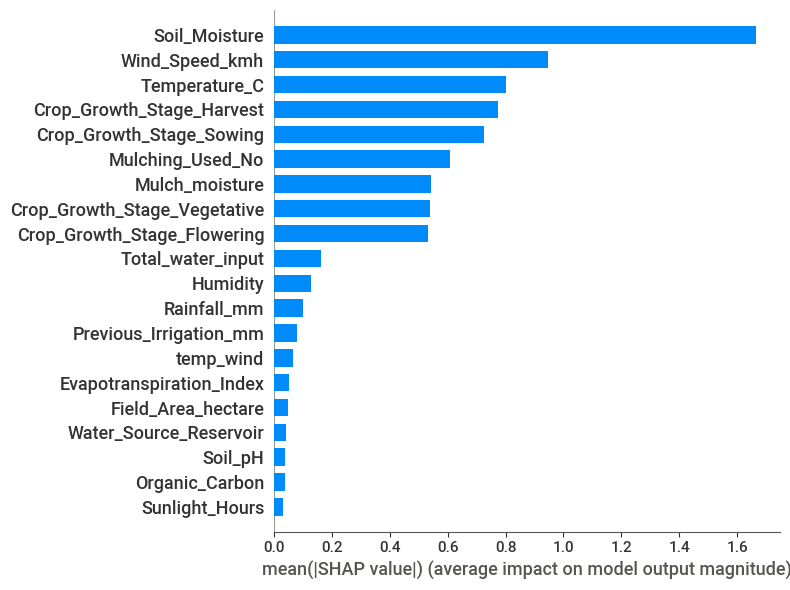

Top 20 features by SHAP:
['Soil_Moisture', 'Wind_Speed_kmh', 'Temperature_C', 'Crop_Growth_Stage_Harvest', 'Crop_Growth_Stage_Sowing', 'Mulching_Used_No', 'Mulch_moisture', 'Crop_Growth_Stage_Vegetative', 'Crop_Growth_Stage_Flowering', 'Total_water_input', 'Humidity', 'Rainfall_mm', 'Previous_Irrigation_mm', 'temp_wind', 'Evapotranspiration_Index', 'Field_Area_hectare', 'Water_Source_Reservoir', 'Soil_pH', 'Organic_Carbon', 'Sunlight_Hours']

X_train_xgb_20 shape: (504000, 20)
X_test_xgb_20 shape:  (126000, 20)


In [30]:
# XGBoost SHAP values on test set
# XGBoost SHAP values on test set
xgb_explainer = shap.TreeExplainer(xgb_model)
xgb_shap_vals = xgb_explainer.shap_values(X_test_xgb_30)

# Handle all shape cases: list, 3D array, or already 2D
if isinstance(xgb_shap_vals, list):
    # Older SHAP: list of arrays, one per class → take class 1
    xgb_shap_vals = xgb_shap_vals[1]
elif xgb_shap_vals.ndim == 3:
    # Newer SHAP: shape (n_samples, n_features, n_classes) → take class 1
    xgb_shap_vals = xgb_shap_vals[:, :, 1]
# else: already (n_samples, n_features), nothing to do

# Confirm it's now 2D
assert xgb_shap_vals.ndim == 2, f"Expected 2D SHAP array, got shape {xgb_shap_vals.shape}"

# Global feature importance bar plot
shap.summary_plot(
    xgb_shap_vals,
    X_test_xgb_30,
    plot_type="bar",
    plot_size=(8, 6)
)

# Top 20 features by mean absolute SHAP value
xgb_shap_importance = pd.DataFrame({
    "feature": X_test_xgb_30.columns,
    "shap_mean_abs": np.abs(xgb_shap_vals).mean(axis=0)  # now guaranteed 1D
}).sort_values("shap_mean_abs", ascending=False)

xgb_top20_features = xgb_shap_importance.head(20)["feature"].tolist()
print("Top 20 features by SHAP:")
print(xgb_top20_features)

# Reduce X_train and X_test to top 20 features
X_train_xgb_20 = X_train_xgb_30[xgb_top20_features]
X_test_xgb_20  = X_test_xgb_30[xgb_top20_features]  # fixed: was X_test_lgb_20

print(f"\nX_train_xgb_20 shape: {X_train_xgb_20.shape}")
print(f"X_test_xgb_20 shape:  {X_test_xgb_20.shape}")

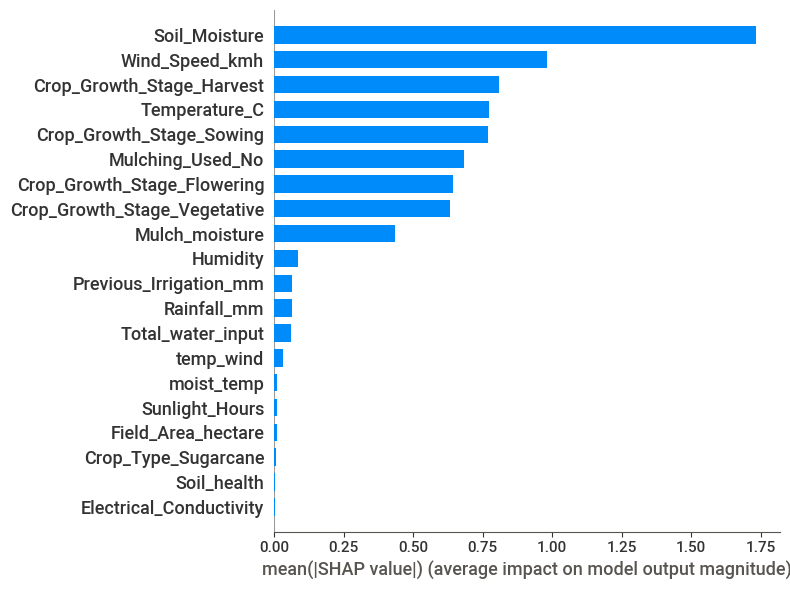

Top 20 features by SHAP:
['Soil_Moisture', 'Wind_Speed_kmh', 'Crop_Growth_Stage_Harvest', 'Temperature_C', 'Crop_Growth_Stage_Sowing', 'Mulching_Used_No', 'Crop_Growth_Stage_Flowering', 'Crop_Growth_Stage_Vegetative', 'Mulch_moisture', 'Humidity', 'Previous_Irrigation_mm', 'Rainfall_mm', 'Total_water_input', 'temp_wind', 'moist_temp', 'Sunlight_Hours', 'Field_Area_hectare', 'Crop_Type_Sugarcane', 'Soil_health', 'Electrical_Conductivity']

X_train_lgb_20 shape: (504000, 20)
X_test_lgb_20 shape:  (126000, 20)


: 

In [ ]:
# LightGBM SHAP values on test set
lgb_explainer = shap.TreeExplainer(lgb_model)
lgb_shap_vals = lgb_explainer.shap_values(X_test_lgb_30)

# Handle all shape cases: list, 3D array, or already 2D
if isinstance(lgb_shap_vals, list):
    # Older SHAP: list of arrays, one per class → take class 1
    lgb_shap_vals = lgb_shap_vals[1]
elif lgb_shap_vals.ndim == 3:
    # Newer SHAP: shape (n_samples, n_features, n_classes) → take class 1
    lgb_shap_vals = lgb_shap_vals[:, :, 1]
# else: already (n_samples, n_features), nothing to do

# Confirm it's now 2D
assert lgb_shap_vals.ndim == 2, f"Expected 2D SHAP array, got shape {lgb_shap_vals.shape}"

# Global feature importance bar plot
shap.summary_plot(
    lgb_shap_vals,
    X_test_lgb_30,  # fixed: was X_test_lgb_50
    plot_type="bar",
    plot_size=(8, 6)
)

# Top 20 features by mean absolute SHAP value
lgb_shap_importance = pd.DataFrame({
    "feature": X_test_lgb_30.columns,  # fixed: was X_test_lgb_50
    "shap_mean_abs": np.abs(lgb_shap_vals).mean(axis=0)
}).sort_values("shap_mean_abs", ascending=False)

lgb_top20_features = lgb_shap_importance.head(20)["feature"].tolist()
print("Top 20 features by SHAP:")
print(lgb_top20_features)

# Reduce X_train and X_test to top 20 features
X_train_lgb_20 = X_train_lgb_30[lgb_top20_features]  # fixed: was X_train_lgb_50
X_test_lgb_20  = X_test_lgb_30[lgb_top20_features]   # fixed: was X_test_lgb_50

print(f"\nX_train_lgb_20 shape: {X_train_lgb_20.shape}")
print(f"X_test_lgb_20 shape:  {X_test_lgb_20.shape}")

In [ ]:
# CatBoost SHAP values on test set
cat_explainer = shap.TreeExplainer(catboost_model)
cat_shap_vals = cat_explainer.shap_values(X_test_cb_30)

# Handle all shape cases: list, 3D array, or already 2D
if isinstance(cat_shap_vals, list):
    # Older SHAP: list of arrays, one per class → take class 1
    cat_shap_vals = cat_shap_vals[1]
elif cat_shap_vals.ndim == 3:
    # Newer SHAP: shape (n_samples, n_features, n_classes) → take class 1
    cat_shap_vals = cat_shap_vals[:, :, 1]
# else: already (n_samples, n_features), nothing to do

# Confirm it's now 2D
assert cat_shap_vals.ndim == 2, f"Expected 2D SHAP array, got shape {cat_shap_vals.shape}"

# Global feature importance bar plot
shap.summary_plot(
    cat_shap_vals,
    X_test_cb_30,
    plot_type="bar",
    plot_size=(8, 6)
)

# Top 20 features by mean absolute SHAP value
cat_shap_importance = pd.DataFrame({
    "feature": X_test_cb_30.columns,
    "shap_mean_abs": np.abs(cat_shap_vals).mean(axis=0)
}).sort_values("shap_mean_abs", ascending=False)

cat_top20_features = cat_shap_importance.head(20)["feature"].tolist()
print("Top 20 features by SHAP:")
print(cat_top20_features)

# Reduce X_train and X_test to top 20 features
X_train_cb_20 = X_train_cb_30[cat_top20_features]
X_test_cb_20  = X_test_cb_30[cat_top20_features]

print(f"\nX_train_cat_20 shape: {X_train_cb_20.shape}")
print(f"X_test_cat_20 shape:  {X_test_cb_20.shape}")

NOTE FOR LATER

{'High': np.int64(0), 'Low': np.int64(1), 'Medium': np.int64(2)}